# Visual Prompting
Got the idea to try this out from [LoR-VP: Low-Rank Visual Prompting for Efficient Vision Model Adaptation](https://arxiv.org/pdf/2502.00896). This notebook is for experimenting with visual prompting to understand how it works.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as T

from torch.utils.data import DataLoader
from torchvision.datasets import CIFAR10

import matplotlib.pyplot as plt

# -------------------------
# 1. Load the frozen, pre-trained model
# -------------------------
model = models.resnet18(weights="IMAGENET1K_V1")
model.eval()
for param in model.parameters():
    param.requires_grad = False

# Replace the classifier from ResNet18 with a new one for CIFAR10 (1000 classes to 10 classes)
model.fc = nn.Linear(512, 10)     # this layer is trainable
# model.fc.requires_grad = True  # default True


# -------------------------
# 2. Create learnable prompt
# -------------------------
prompt = nn.Parameter(torch.zeros(3, 224, 224))

# -------------------------
# 3. Prepare dataset
# -------------------------
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
])

dataset = CIFAR10(root="./data", train=True, download=False, transform=transform)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

# -------------------------
# 4. Optimizer (only prompt + classifier head)
# -------------------------
optimizer = torch.optim.Adam(
    list(model.fc.parameters()) + [prompt],
    lr=1e-3
)

criterion = nn.CrossEntropyLoss()
training_losses = []

# -------------------------
# 5. Training loop
# -------------------------
for epoch in range(2):
    for images, labels in loader:

        prompted_images = images + prompt

        logits = model(prompted_images)
        loss = criterion(logits, labels)

        training_losses.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch}  Loss: {loss.item():.4f}")

print("Training complete")

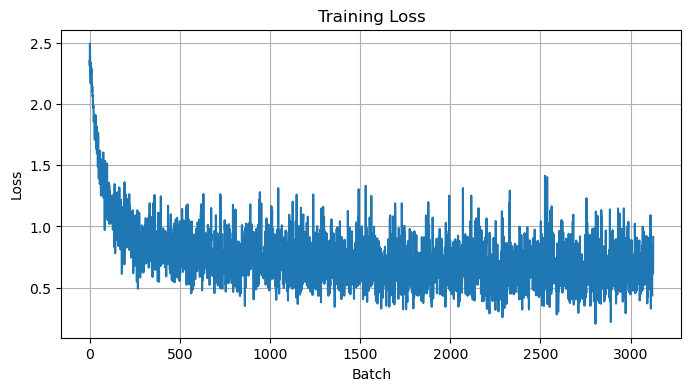

In [3]:
plt.figure(figsize=(8, 4))
plt.plot(training_losses)
plt.title("Training Loss")
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()